In [20]:
import numpy as np
import xarray as xr

In [21]:
month = 5

In [22]:
# JdF box, including cells to 50 m depth
ii1, ii2 = 300, 365
jj1, jj2 = 50, 100
km = 24

In [23]:
pp = xr.open_dataset(
    '/results2/SalishSea/month-avg.202111/SalishSeaCast_month_climatology_prod_T_20070101_20231231.nc')

In [24]:
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask202108.nc')

In [25]:
volume = mesh.tmask * mesh.e1t * mesh.e2t * mesh.e3t_0
denominator = np.nansum(
    np.array(volume[0, 0:km, ii1:ii2, jj1:jj2]))

In [26]:
climate = pp.PPDIATNO3[month-1] + pp.PPPHYNO3[month-1]

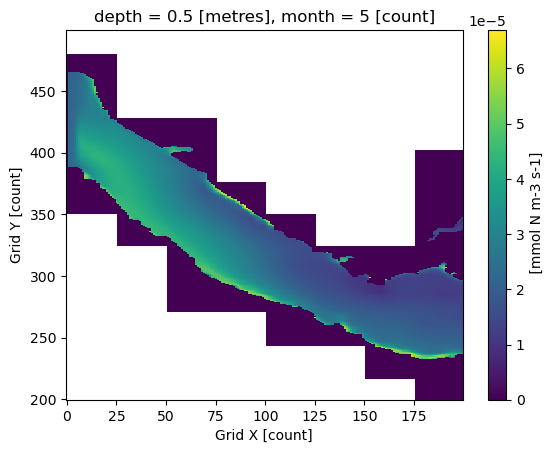

In [27]:
climate[0, 200:500, 0:200].plot();

In [28]:
numerator = np.nansum(
    np.array(climate[0:km, ii1:ii2, jj1:jj2]) * np.array(volume[0, 0:km, ii1:ii2, jj1:jj2]))

In [29]:
climatology_average_productivity = numerator/denominator * 86400
climatology_average_productivity

np.float64(0.35201699960169425)

In [30]:
if month in [5, 7, 8]:
    endday = 31
elif month in [4, 6, 9]:
    endday = 30

hw2014 = xr.open_dataset(
    f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_prod_T_20140{month}01_20140{month}{endday}.nc')
hw2015 = xr.open_dataset(
    f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_prod_T_20150{month}01_20150{month}{endday}.nc')
hw2016 = xr.open_dataset(
    f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_prod_T_20160{month}01_20160{month}{endday}.nc')
hw2017 = xr.open_dataset(
    f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_prod_T_20170{month}01_20170{month}{endday}.nc')

In [31]:
hw = (hw2014.PPDIATNO3[0] + hw2015.PPDIATNO3[0] + hw2016.PPDIATNO3[0] + hw2017.PPDIATNO3[0] +
      hw2014.PPPHYNO3[0] + hw2015.PPPHYNO3[0] + hw2016.PPPHYNO3[0] + hw2017.PPPHYNO3[0])/ 4.

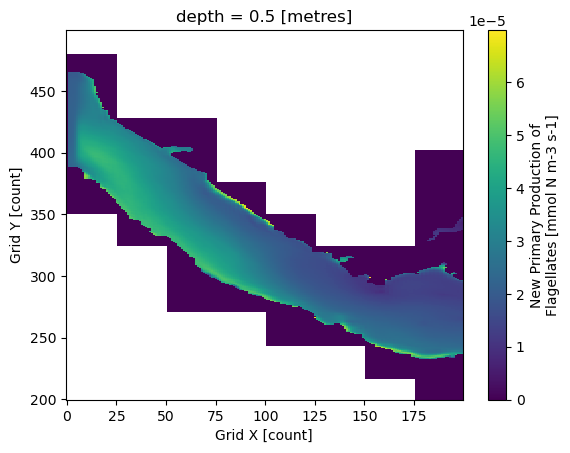

In [32]:
hw[0, 200:500, 0:200].plot();

In [33]:
numerator_hw = np.nansum(
    np.array(hw[0:km, ii1:ii2, jj1:jj2]) * np.array(volume[0, 0:km, ii1:ii2, jj1:jj2]))

In [34]:
hw_average_productivity = numerator_hw/denominator * 86400
hw_average_productivity

np.float64(0.38432822227854724)

In [35]:
# Central part of JdF Strait about 60 km long
# Currents in July in upper JdF about 30 cm/s based on Thomson et al 2007 Fig 6
time = 60e3/0.3 / 86400 # in days
time

2.314814814814815

In [36]:
time * (hw_average_productivity - climatology_average_productivity)

np.float64(0.0747944969371597)

In [37]:
time * (hw_average_productivity - climatology_average_productivity) / 2.1

np.float64(0.03561642711293319)

In [19]:
(0.0700 + 0.0748 + 0.0449 - 0.0578 + 0.0271 - 0.0092)/6

0.024966666666666675

In [38]:
0.384-0.352

0.03200000000000003